## 01_EDA
### Exploratory Data Analysis
### BRFSS Diabetes Dataset

In [13]:
# 导入包
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

#plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

sns.set_style("whitegrid")

In [14]:
#创建输出文件夹

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

In [15]:
# 读取数据

DATA_PATH = r"D:\人工智能与生物应用学导论\项目作业\archive\diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_PATH)

print("="*60)
print("数据集信息")
print("="*60)

print("Shape:", df.shape)

print("\n缺失值统计：")
print(df.isnull().sum())

数据集信息
Shape: (253680, 22)

缺失值统计：
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64



类别分布：
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


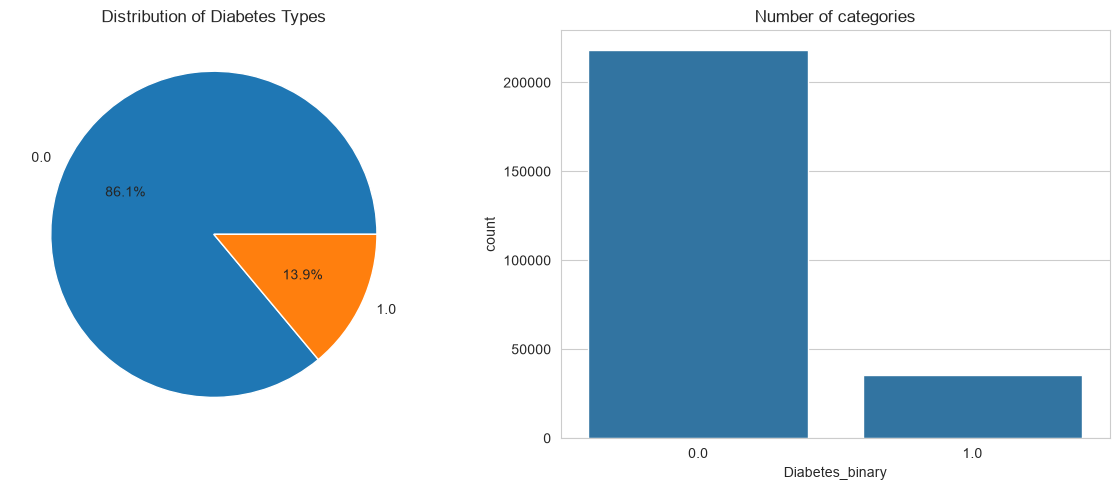

In [16]:
# 基本信息
TARGET = "Diabetes_binary"

print("\n类别分布：")
print(df[TARGET].value_counts())

# Figure 1
# 类别分布
fig, ax = plt.subplots(1,2,figsize=(12,5))

# 饼图
df[TARGET].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax[0])

ax[0].set_ylabel("")
ax[0].set_title("Distribution of Diabetes Types")

# 条形图
sns.countplot(
    x=TARGET,
    data=df,
    ax=ax[1])

ax[1].set_title("Number of categories")

plt.tight_layout()

plt.savefig(
    "figures/Figure1_Class_Distribution.png",
    dpi=300)

plt.show()

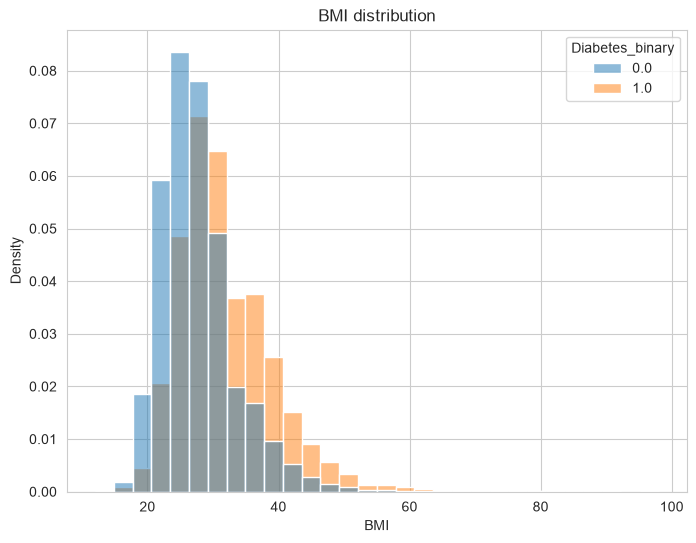

In [17]:
# BMI 分布
if "BMI" in df.columns:

    plt.figure(figsize=(8,6))

    sns.histplot(
        data=df,
        x="BMI",
        hue=TARGET,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.5)

    plt.title("BMI distribution")

    plt.savefig(
        "figures/Figure2_BMI_Distribution.png",
        dpi=300)

    plt.show()

In [18]:
# 特征分类
binary_features = [
    c for c in df.columns
    if c != TARGET
    and df[c].nunique()==2]

ordinal_features = [
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Income",
    "Education",
    "Age"]

ordinal_features = [
    c for c in ordinal_features
    if c in df.columns]

continuous_features = []

if "BMI" in df.columns:
    continuous_features.append("BMI")

print("\n二元变量:")
print(binary_features)

print("\n有序变量:")
print(ordinal_features)


二元变量:
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

有序变量:
['GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education', 'Age']


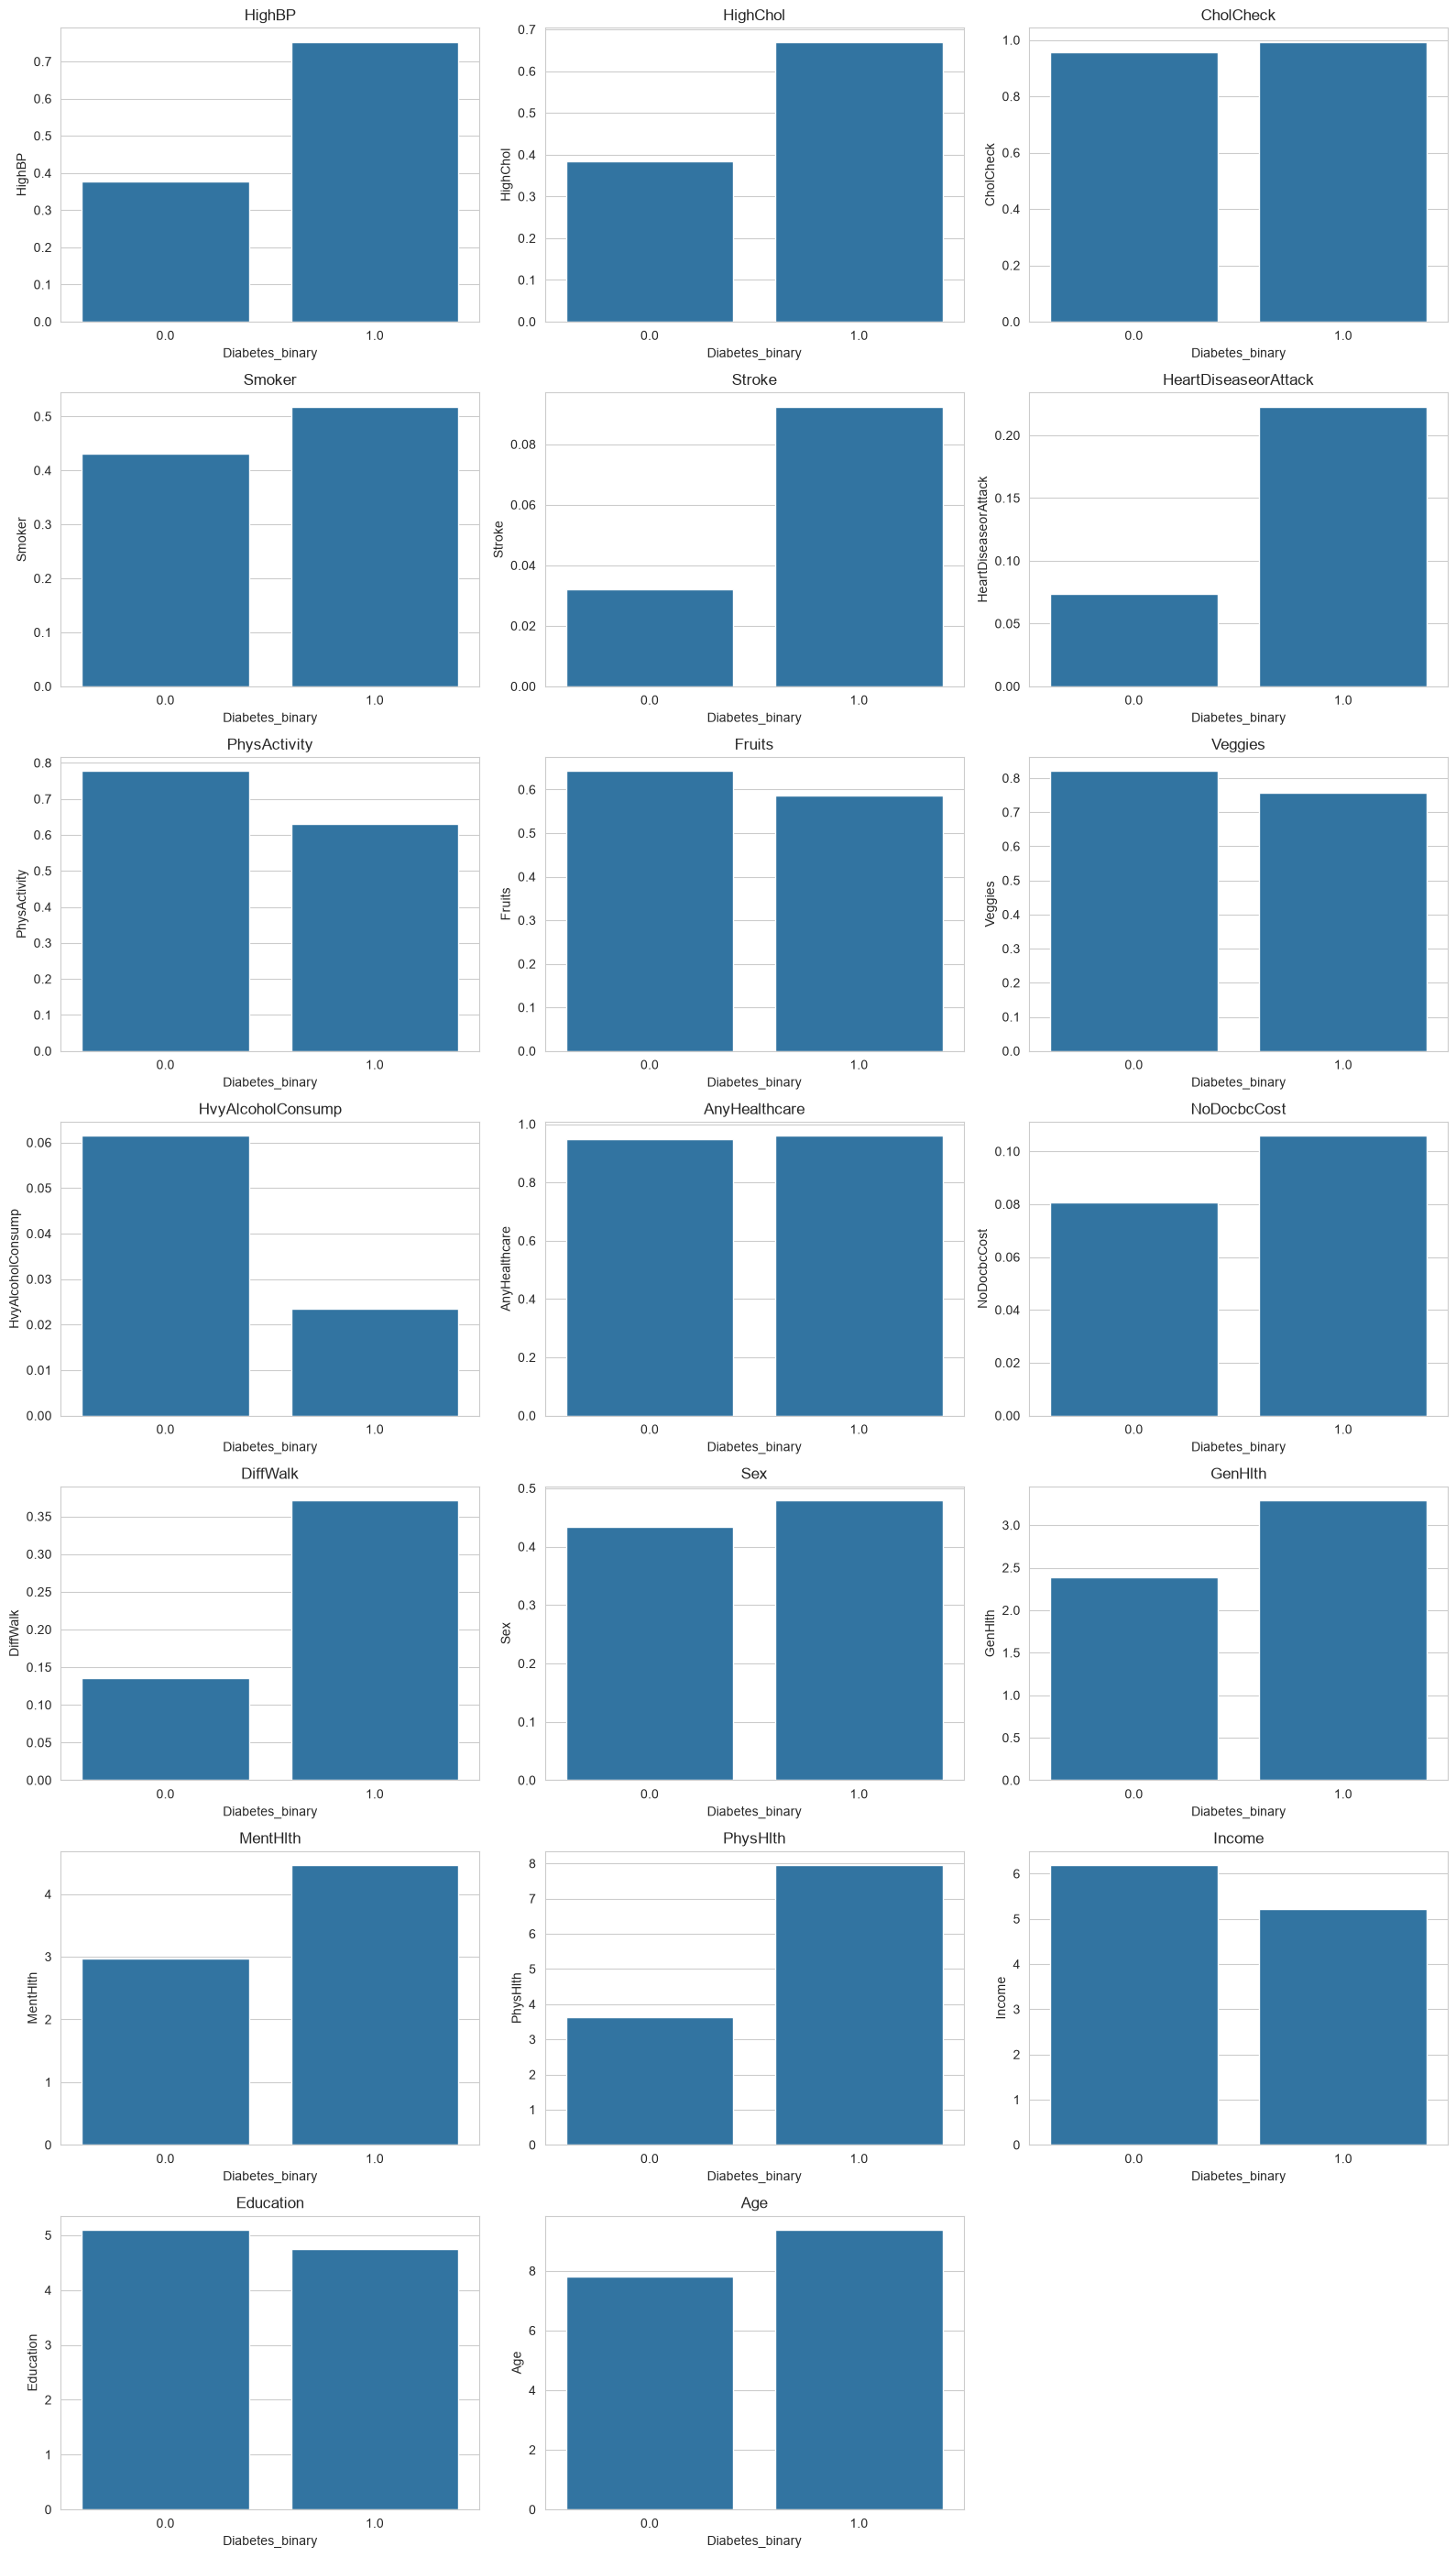

In [19]:
# Figure 3
# 特征差异图
plot_features = binary_features + ordinal_features

ncols = 3
nrows = int(np.ceil(len(plot_features)/ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16,4*nrows))

axes = axes.flatten()

for i, feature in enumerate(plot_features):

    temp = (
        df.groupby(TARGET)[feature]
        .mean()
        .reset_index())

    sns.barplot(
        x=TARGET,
        y=feature,
        data=temp,
        ax=axes[i])

    axes[i].set_title(feature)

for j in range(i+1,len(axes)):
    axes[j].axis("off")

plt.tight_layout()

plt.savefig(
    "figures/Figure3_Feature_Comparison.png",
    dpi=300)

plt.show()

In [20]:
# Table 1
# 统计检验
results = []

group0 = df[df[TARGET]==0]
group1 = df[df[TARGET]==1]

# 连续变量
for feature in continuous_features:

    stat,p = ttest_ind(
        group0[feature],
        group1[feature])

    results.append([
        feature,
        "T-test",
        stat,
        p])
    
# 分类变量
cat_features = binary_features + ordinal_features

for feature in cat_features:

    table = pd.crosstab(
        df[feature],
        df[TARGET])

    chi2,p,_,_ = chi2_contingency(table)

    results.append([
        feature,
        "Chi-square",
        chi2,
        p])

In [21]:
# 整理结果

stats_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Test",
        "Statistic",
        "P_value"
    ]
)

stats_df["Significant"] = np.where(
    stats_df["P_value"] < 0.05,
    "*",
    "")

stats_df = stats_df.sort_values("P_value")

print("\n统计检验结果")
print(stats_df)

stats_df.to_csv(
    "tables/feature_significance.csv",
    index=False)


统计检验结果
                 Feature        Test     Statistic        P_value Significant
0                    BMI      T-test   -111.878142   0.000000e+00           *
1                 HighBP  Chi-square  17562.446090   0.000000e+00           *
2               HighChol  Chi-square  10174.074889   0.000000e+00           *
5                 Stroke  Chi-square   2838.916547   0.000000e+00           *
7           PhysActivity  Chi-square   3539.419370   0.000000e+00           *
6   HeartDiseaseorAttack  Chi-square   7971.155841   0.000000e+00           *
13              DiffWalk  Chi-square  12092.319741   0.000000e+00           *
15               GenHlth  Chi-square  22728.069055   0.000000e+00           *
20                   Age  Chi-square   8795.050614   0.000000e+00           *
19             Education  Chi-square   4027.112282   0.000000e+00           *
18                Income  Chi-square   7003.715091   0.000000e+00           *
17              PhysHlth  Chi-square   8078.527635   0.0

In [22]:
# Table1 基线特征统计
table1 = []

for col in df.columns:

    if col == TARGET:
        continue

    mean0 = group0[col].mean()
    mean1 = group1[col].mean()

    table1.append([col, mean0, mean1])

table1 = pd.DataFrame(
    table1,
    columns=[
        "Feature",
        "Non_Diabetes",
        "Diabetes"
    ]
)

table1.to_csv("tables/Table1_Baseline.csv", index=False)

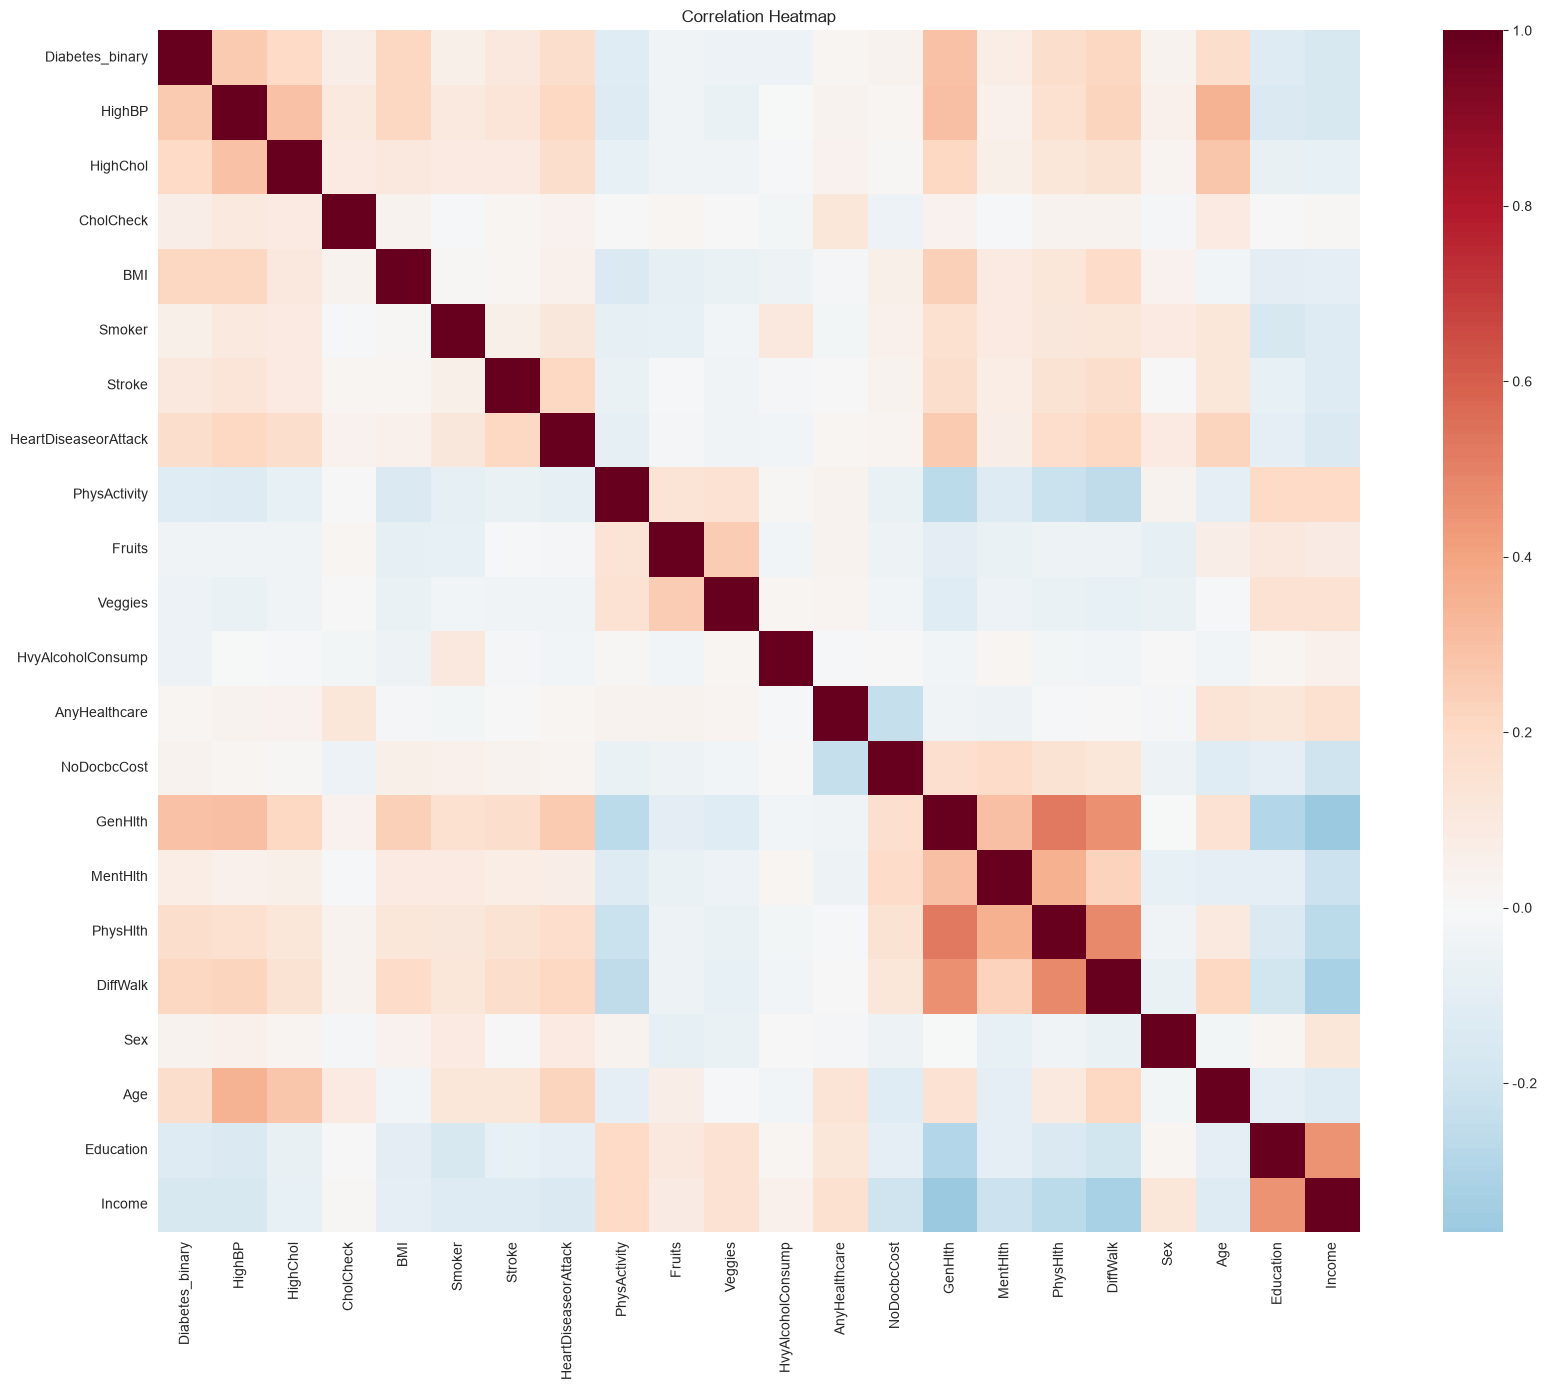

In [23]:
# Figure 4
# Correlation Heatmap 相关性热力图

corr = df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    square=True)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "figures/Figure4_Correlation_Heatmap.png",
    dpi=300)

plt.show()

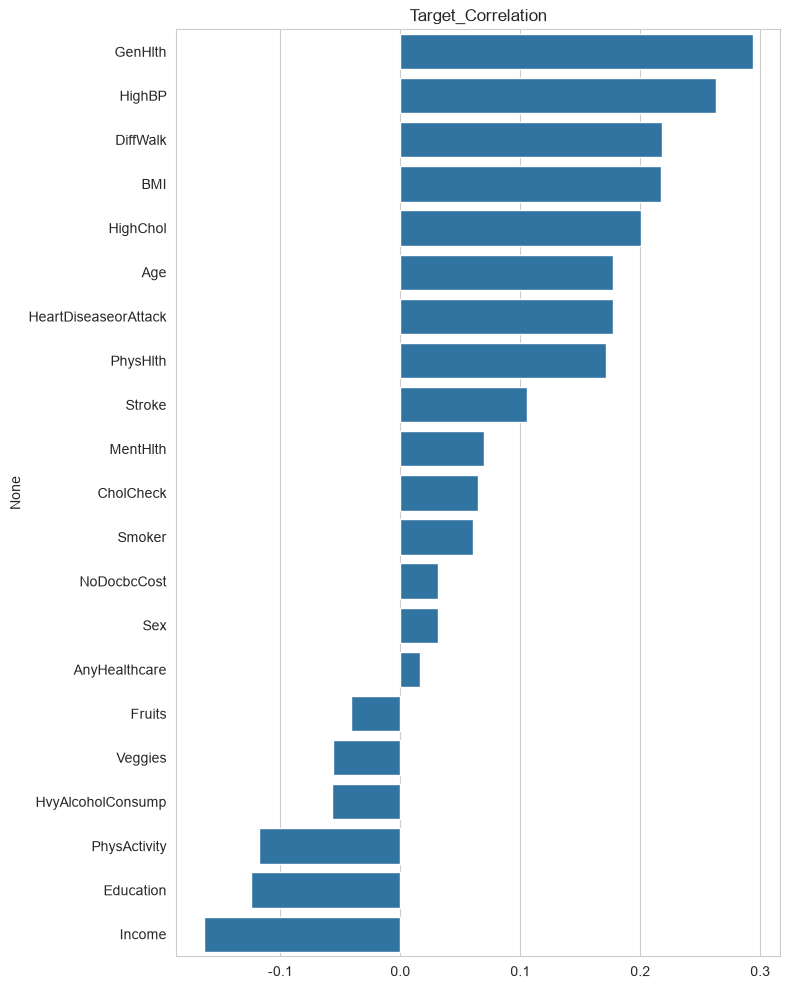


EDA完成
结果已保存至:
figures/
tables/


In [24]:
# 与糖尿病相关性排序
# 特征与糖尿病相关性


target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(8,10))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Target_Correlation")

plt.tight_layout()

plt.savefig(
    "figures/Figure5_Target_Correlation.png",
    dpi=300
)

plt.show()

target_corr.to_csv(
    "tables/Target_Correlation.csv"
)

print("\nEDA完成")
print("结果已保存至:")
print("figures/")
print("tables/")